In [205]:
import kagglehub
import pandas as pd
import os
import missingno as msno
import seaborn as sns
import matplotlib.pyplot as plt

In [206]:
import kagglehub

# Download latest version
path = kagglehub.dataset_download("shivamb/netflix-shows")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'netflix-shows' dataset.
Path to dataset files: /kaggle/input/netflix-shows


In [207]:
files = os.listdir(path)
print(files)

['netflix_titles.csv']


In [208]:
df = pd.read_csv(os.path.join(path, "netflix_titles.csv"))
df.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [209]:
df.shape

(8807, 12)

In [210]:
df.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


In [211]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


In [212]:
df.duration

,duration
0,90 min
1,2 Seasons
2,1 Season
3,1 Season
4,2 Seasons
...,...
8802,158 min
8803,2 Seasons
8804,88 min
8805,88 min


In [213]:
df_movies = df[df["duration"].str.contains("min", na=False)]
df_movies.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...
12,s13,Movie,Je Suis Karl,Christian Schwochow,"Luna Wedler, Jannis Niewöhner, Milan Peschel, ...","Germany, Czech Republic","September 23, 2021",2021,TV-MA,127 min,"Dramas, International Movies",After most of her family is murdered in a terr...


In [214]:
df_movies["duration"] = df_movies["duration"].apply(lambda x: x.replace(" min","")).astype(int).copy()
df_movies["duration"]

/tmp/ipykernel_188/929951713.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_movies["duration"] = df_movies["duration"].apply(lambda x: x.replace(" min","")).astype(int).copy()


,duration
0,90
6,91
7,125
9,104
12,127
...,...
8801,96
8802,158
8804,88
8805,88


In [215]:
df_movies.describe()

,release_year,duration
count,6128.000000,6128.000000
mean,2013.121084,99.577187
std,9.680300,28.290593
min,1942.000000,3.000000
25%,2012.000000,87.000000
50%,2016.000000,98.000000
75%,2018.000000,114.000000
max,2021.000000,312.000000


In [216]:
df.dtypes

,0
show_id,object
type,object
title,object
director,object
cast,object
country,object
date_added,object
release_year,int64
rating,object
duration,object


In [217]:
df.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


In [218]:
df.isnull().sum()

,0
show_id,0
type,0
title,0
director,2634
cast,825
country,831
date_added,10
release_year,0
rating,4
duration,3


<Axes: >

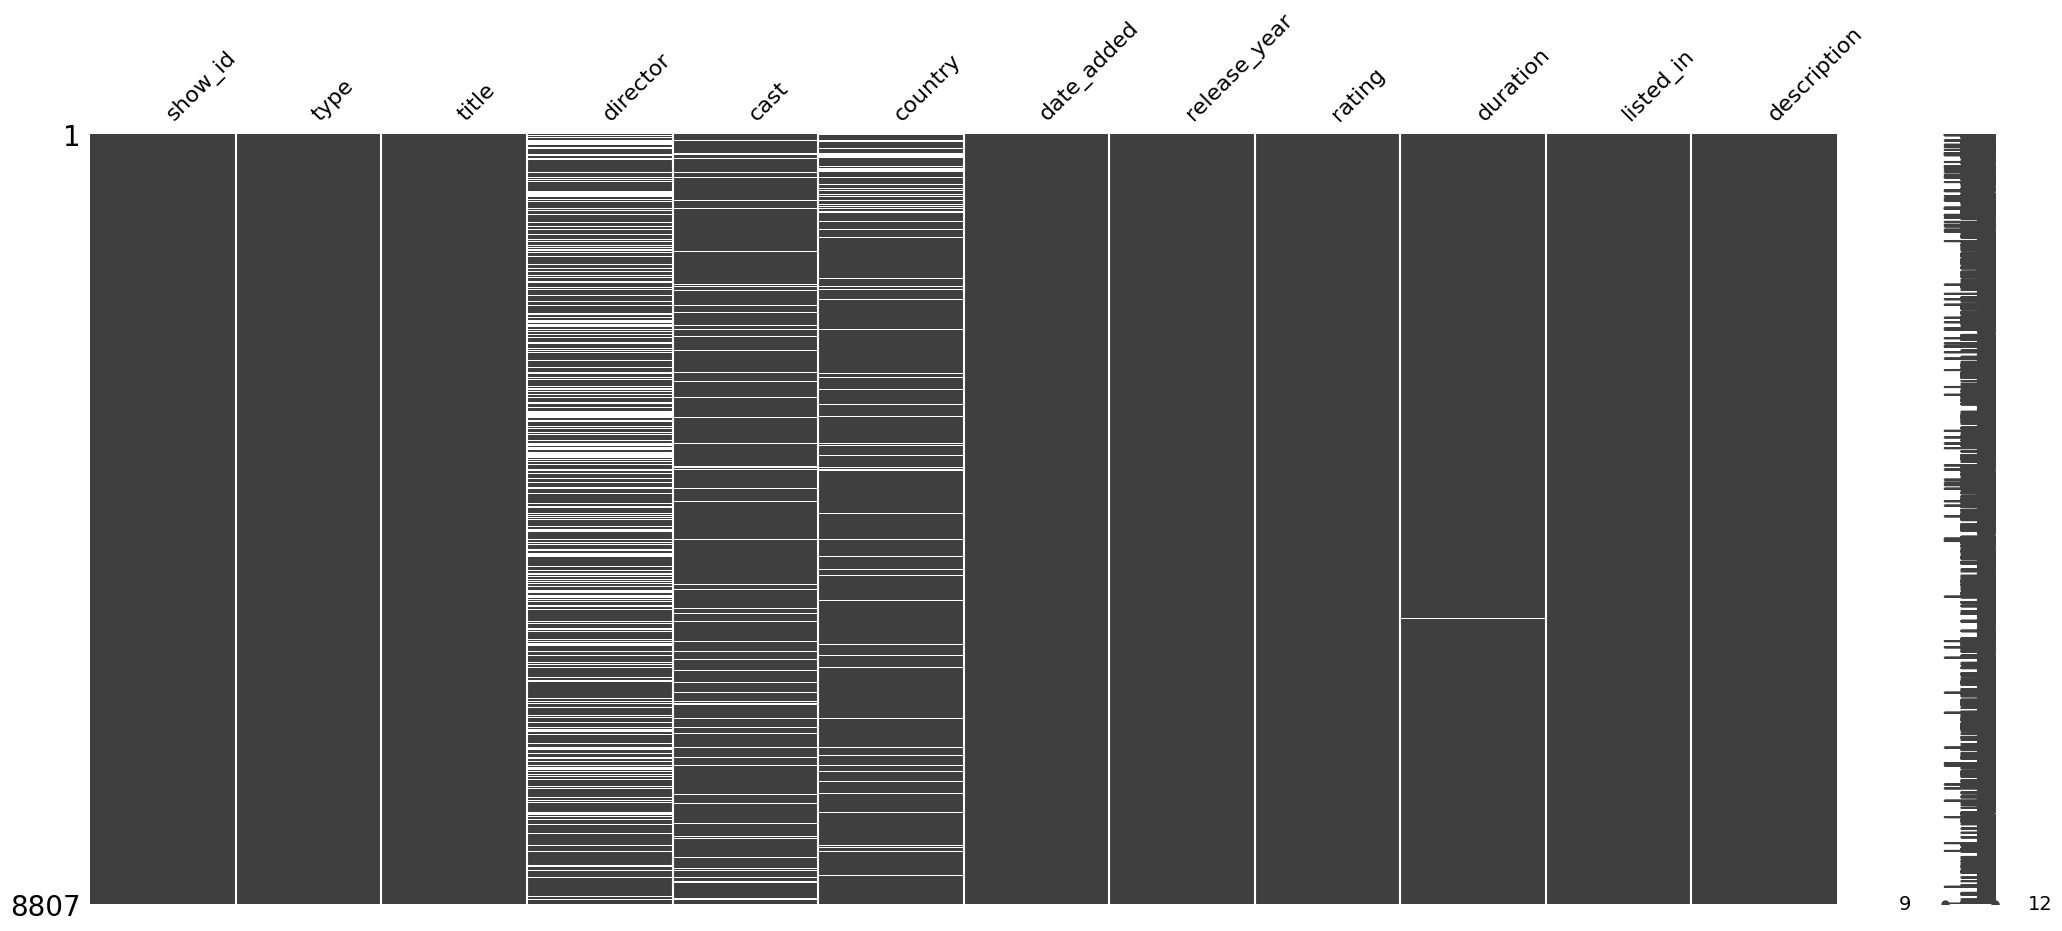

In [219]:
msno.matrix(df)

<Axes: >

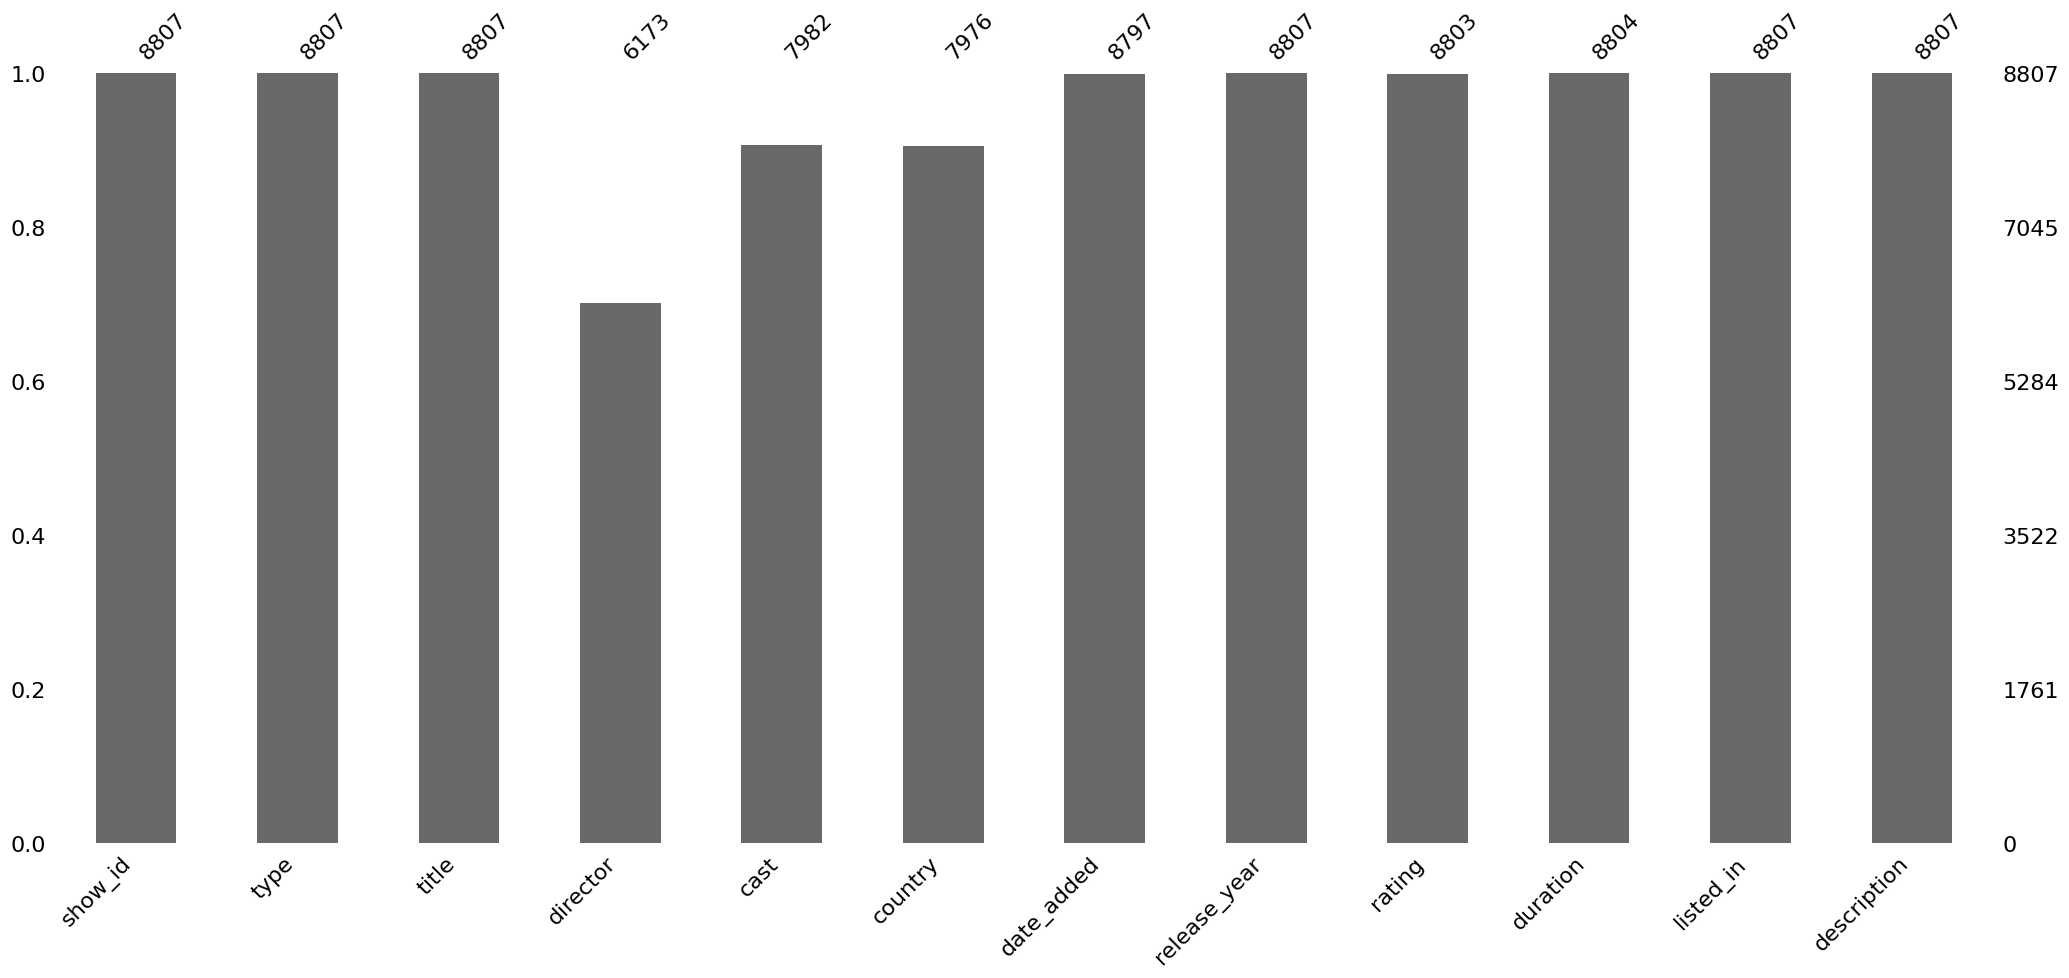

In [220]:
msno.bar(df)

<Axes: >

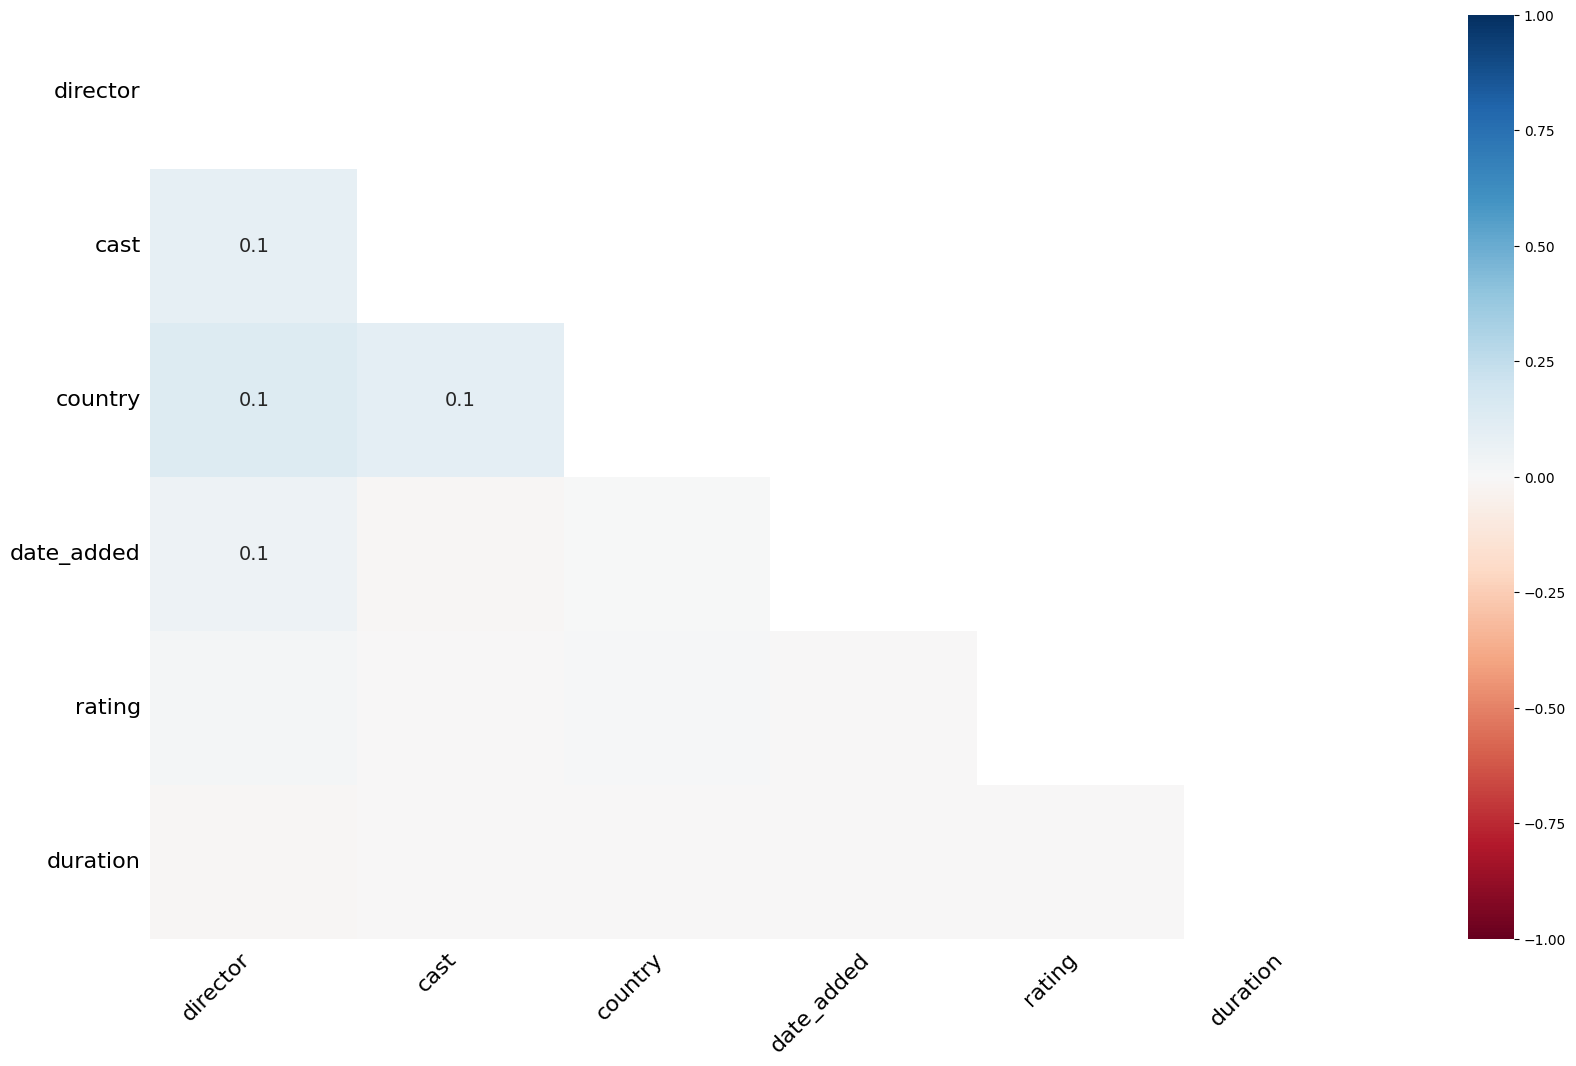

In [221]:
msno.heatmap(df)

<Axes: >

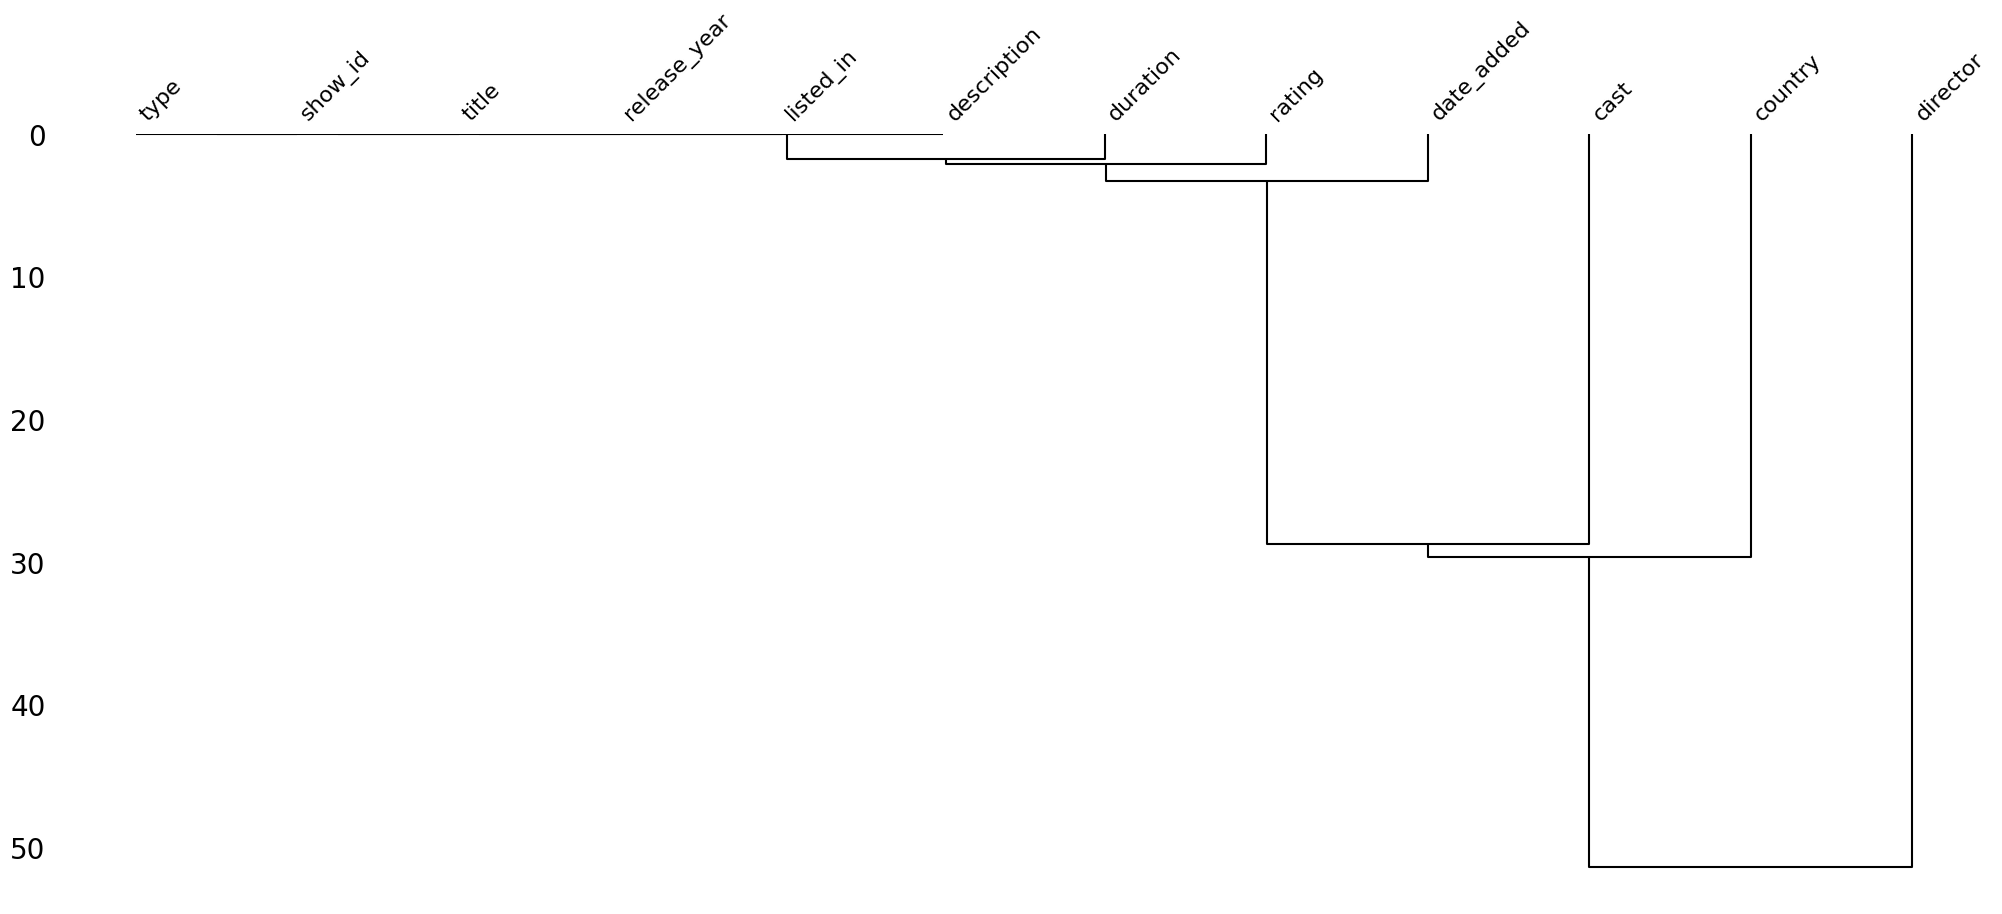

In [222]:
msno.dendrogram(df)

In [223]:
countries = df["country"].dropna().str.split(", ")

In [224]:
countries = countries.explode()
country_counts = countries.value_counts()

In [225]:
country_pct = countries.value_counts(normalize=True) * 100

In [226]:
country_stats = country_pct.reset_index()
country_stats.columns = ["Country", "Percentage"]

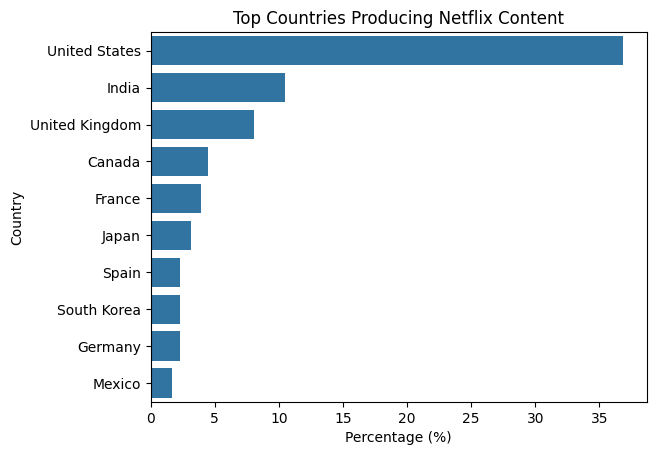

In [227]:
top10 = countries.value_counts(normalize=True).head(10) * 100

sns.barplot(x=top10.values, y=top10.index)
plt.xlabel("Percentage (%)")
plt.ylabel("Country")
plt.title("Top Countries Producing Netflix Content")
plt.show()

In [228]:
df_countries = df.dropna(subset=["country"]).copy()

df_countries["country"] = df_countries["country"].str.split(", ")
df_countries = df_countries.explode("country")

In [229]:
tbl1 = pd.crosstab(df_countries["country"], df_countries["rating"])

In [230]:
tbl_pct1 = tbl1.div(tbl1.sum(axis=1), axis=0) * 100

In [231]:
top = df_countries["country"].value_counts().head(10).index

tbl_pct1.loc[top]

rating,66 min,74 min,84 min,G,NC-17,NR,PG,PG-13,R,TV-14,TV-G,TV-MA,TV-PG,TV-Y,TV-Y7,TV-Y7-FV,UR
country,,,,,,,,,,,,,,,,,
United States,0.027108,0.027108,0.027108,1.057197,0.027108,1.165628,6.587151,11.737598,17.891027,13.472486,2.412578,29.818379,8.240716,3.442667,3.984820,0.054215,0.027108
India,0.000000,0.000000,0.000000,0.000000,0.000000,0.669216,0.669216,1.051625,0.478011,54.684512,0.956023,25.430210,13.766730,0.573614,1.625239,0.095602,0.000000
United Kingdom,0.000000,0.000000,0.000000,0.497512,0.000000,1.492537,4.353234,10.447761,18.034826,12.810945,3.109453,31.218905,12.189055,4.228856,1.492537,0.000000,0.124378
Canada,0.000000,0.000000,0.000000,0.449438,0.224719,1.123596,7.415730,7.191011,17.752809,11.011236,3.820225,24.044944,8.764045,10.112360,7.865169,0.224719,0.000000
France,0.000000,0.000000,0.000000,0.508906,0.254453,1.017812,5.343511,8.905852,14.503817,12.213740,1.526718,41.475827,3.053435,5.343511,5.343511,0.000000,0.508906
Japan,0.000000,0.000000,0.000000,0.315457,0.000000,0.000000,3.470032,2.839117,2.839117,31.230284,0.630915,31.861199,15.772871,0.946372,10.094637,0.000000,0.000000
Spain,0.000000,0.000000,0.000000,1.293103,0.431034,0.431034,1.724138,2.155172,5.603448,7.758621,0.431034,73.275862,4.310345,2.155172,0.431034,0.000000,0.000000
South Korea,0.000000,0.000000,0.000000,0.432900,0.000000,1.731602,0.865801,0.432900,0.865801,37.229437,0.432900,39.826840,8.225108,3.896104,6.060606,0.000000,0.000000
Germany,0.000000,0.000000,0.000000,0.442478,0.000000,0.884956,3.539823,13.716814,19.026549,11.946903,3.982301,34.955752,7.522124,1.327434,2.654867,0.000000,0.000000


In [232]:
df['rating'].groupby(df['rating']).count()

,rating
rating,
66 min,1
74 min,1
84 min,1
G,41
NC-17,3
NR,80
PG,287
PG-13,490
R,799


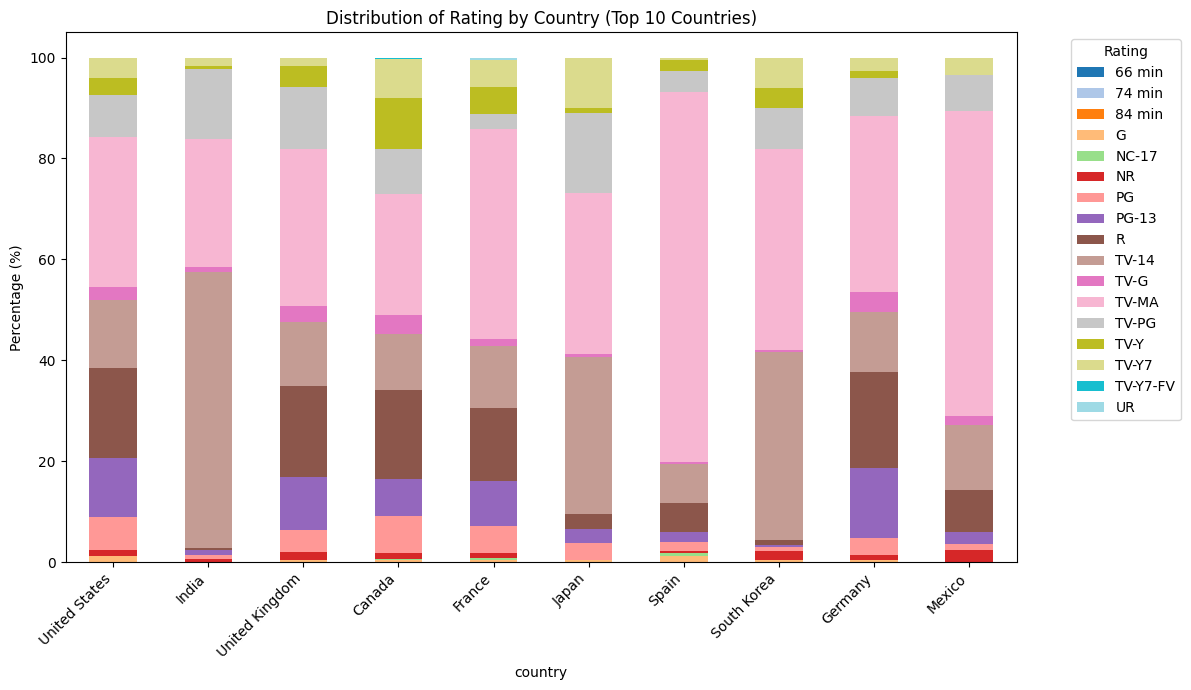

In [233]:
tbl_pct1.loc[top].plot(kind="bar", stacked=True, figsize=(12,7), colormap="tab20")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Rating by Country (Top 10 Countries)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Rating", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [234]:
tbl = pd.crosstab(df_countries["country"], df_countries["type"])

In [235]:
tbl_pct = tbl.div(tbl.sum(axis=1), axis=0) * 100

In [236]:
tbl_pct = tbl_pct.round(2)

In [237]:
df_countries["country"].groupby(df_countries["country"])
df_countries["country"]

,country
0,United States
1,South Africa
4,India
7,United States
7,Ghana
...,...
8801,Jordan
8802,United States
8804,United States
8805,United States


In [238]:
top = df_countries["country"].value_counts().head(10).index

tbl_pct.loc[top]

type,Movie,TV Show
country,,
United States,74.57,25.43
India,91.97,8.03
United Kingdom,66.17,33.83
Canada,71.69,28.31
France,77.10,22.90
Japan,37.42,62.58
Spain,73.71,26.29
South Korea,26.41,73.59
Germany,80.53,19.47


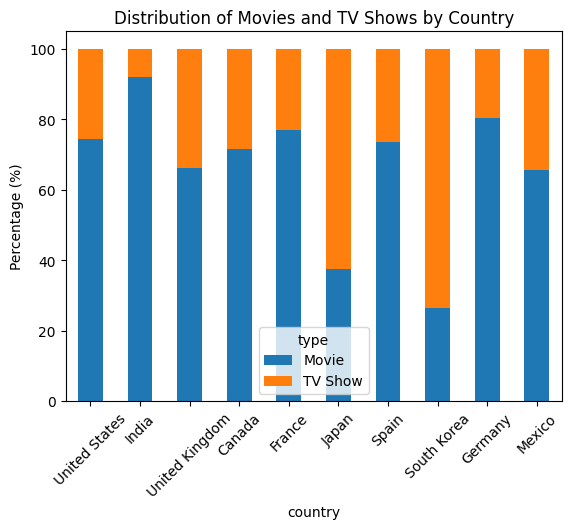

In [239]:
tbl_pct.loc[top].plot(kind="bar", stacked=True)
plt.ylabel("Percentage (%)")
plt.title("Distribution of Movies and TV Shows by Country")
plt.xticks(rotation=45)
plt.show()

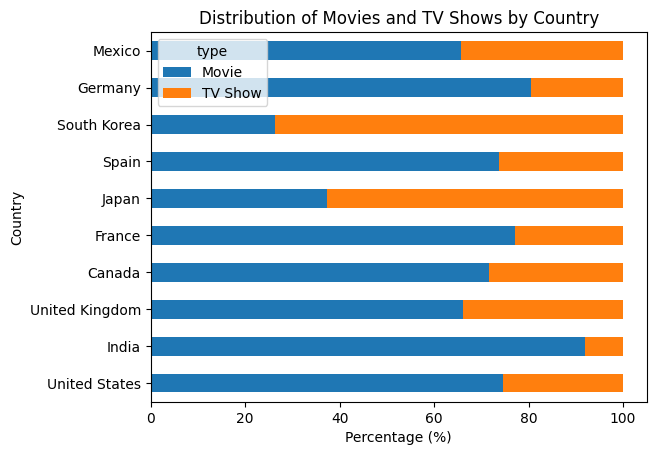

In [240]:
tbl_pct.loc[top].plot(kind="barh", stacked=True)

plt.xlabel("Percentage (%)")
plt.ylabel("Country")
plt.title("Distribution of Movies and TV Shows by Country")

plt.show()

In [241]:
df.head(20)

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...
5,s6,TV Show,Midnight Mass,Mike Flanagan,"Kate Siegel, Zach Gilford, Hamish Linklater, H...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"TV Dramas, TV Horror, TV Mysteries",The arrival of a charismatic young priest brin...
6,s7,Movie,My Little Pony: A New Generation,"Robert Cullen, José Luis Ucha","Vanessa Hudgens, Kimiko Glenn, James Marsden, ...",NaN,"September 24, 2021",2021,PG,91 min,Children & Family Movies,Equestria's divided. But a bright-eyed hero be...
7,s8,Movie,Sankofa,Haile Gerima,"Kofi Ghanaba, Oyafunmike Ogunlano, Alexandra D...","United States, Ghana, Burkina Faso, United Kin...","September 24, 2021",1993,TV-MA,125 min,"Dramas, Independent Movies, International Movies","On a photo shoot in Ghana, an American model s..."
8,s9,TV Show,The Great British Baking Show,Andy Devonshire,"Mel Giedroyc, Sue Perkins, Mary Berry, Paul Ho...",United Kingdom,"September 24, 2021",2021,TV-14,9 Seasons,"British TV Shows, Reality TV",A talented batch of amateur bakers face off in...
9,s10,Movie,The Starling,Theodore Melfi,"Melissa McCarthy, Chris O'Dowd, Kevin Kline, T...",United States,"September 24, 2021",2021,PG-13,104 min,"Comedies, Dramas",A woman adjusting to life after a loss contend...


In [242]:
df_genres = df.dropna(subset=["listed_in"]).copy()
df_genres["listed_in"] = df_genres["listed_in"].str.split(", ")
df_genres = df_genres.explode("listed_in")

In [243]:
genre_counts = df_genres["listed_in"].value_counts()
genre_pct = df_genres["listed_in"].value_counts(normalize=True) * 100
genre_pct = genre_pct.round(2)

In [244]:
tbl_genres = pd.crosstab(df_genres["listed_in"], df_genres["type"])
tbl_genres_pct = tbl_genres.div(tbl_genres.sum(axis=1), axis=0) * 100
tbl_genres_pct = tbl_genres_pct.round(2)

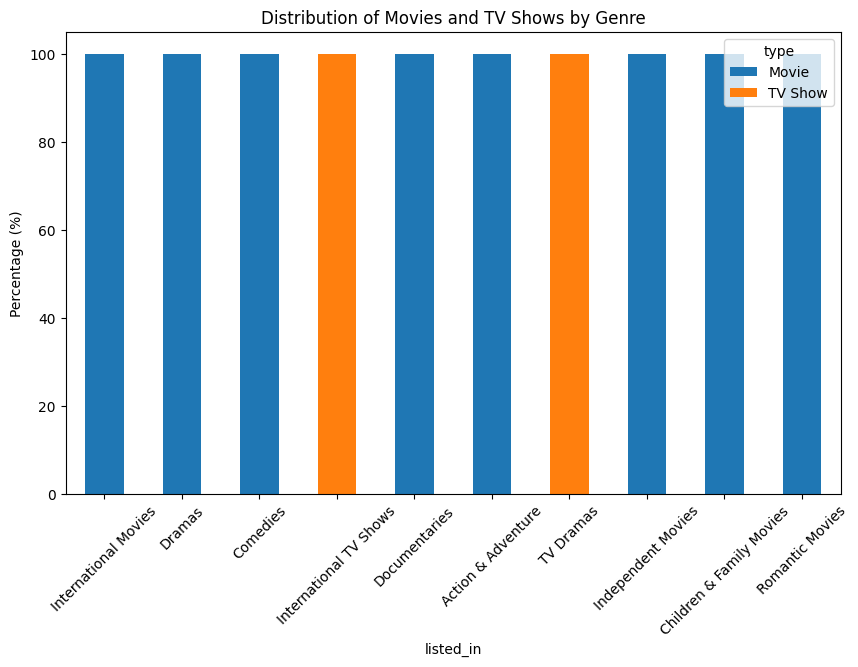

In [245]:
top10_genres = df_genres["listed_in"].value_counts().head(10).index

tbl_genres_pct.loc[top10_genres].plot(kind="bar", stacked=True, figsize=(10,6))
plt.ylabel("Percentage (%)")
plt.title("Distribution of Movies and TV Shows by Genre")
plt.xticks(rotation=45)
plt.show()

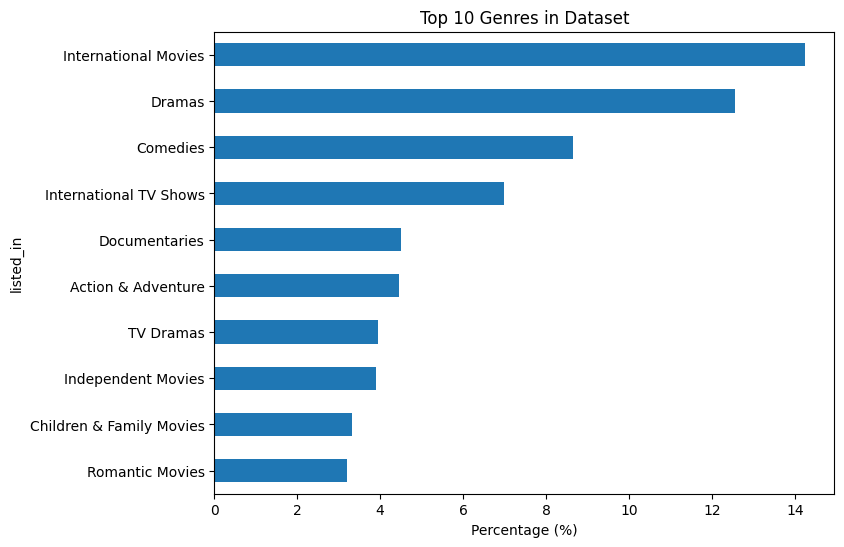

In [246]:
genre_pct.loc[top10_genres].sort_values().plot(kind="barh", figsize=(8,6))
plt.xlabel("Percentage (%)")
plt.title("Top 10 Genres in Dataset")
plt.show()

In [247]:
df_cg = df.dropna(subset=["country", "listed_in"]).copy()
df_cg["country"] = df_cg["country"].str.split(", ")
df_cg["listed_in"] = df_cg["listed_in"].str.split(", ")

df_cg = df_cg.explode("country").explode("listed_in")

In [248]:
tbl_country_genre = pd.crosstab(df_cg["country"], df_cg["listed_in"])

In [249]:
tbl_country_genre_pct = tbl_country_genre.div(tbl_country_genre.sum(axis=1), axis=0) * 100
tbl_country_genre_pct = tbl_country_genre_pct.round(2)

In [250]:
df_cg

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Dramas,"After crossing paths at a party, a Cape Town t..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,TV Mysteries,"After crossing paths at a party, a Cape Town t..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,International TV Shows,In a city of coaching centers known to train I...
...,...,...,...,...,...,...,...,...,...,...,...,...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,Children & Family Movies,"Dragged from civilian life, a former superhero..."
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,Comedies,"Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,Dramas,A scrappy but poor boy worms his way into a ty...
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,International Movies,A scrappy but poor boy worms his way into a ty...


In [251]:
top_countries = df_cg["country"].value_counts().head(10).index
tbl_top_countries = tbl_country_genre_pct.loc[top_countries]

In [252]:
df_cg["country"].groupby(df_cg["country"])
df_cg["country"]

,country
0,United States
1,South Africa
1,South Africa
1,South Africa
4,India
...,...
8805,United States
8805,United States
8806,India
8806,India


In [253]:
df_cg["listed_in"].groupby(df_cg["listed_in"])
df_cg["listed_in"]

,listed_in
0,Documentaries
1,International TV Shows
1,TV Dramas
1,TV Mysteries
4,International TV Shows
...,...
8805,Children & Family Movies
8805,Comedies
8806,Dramas
8806,International Movies


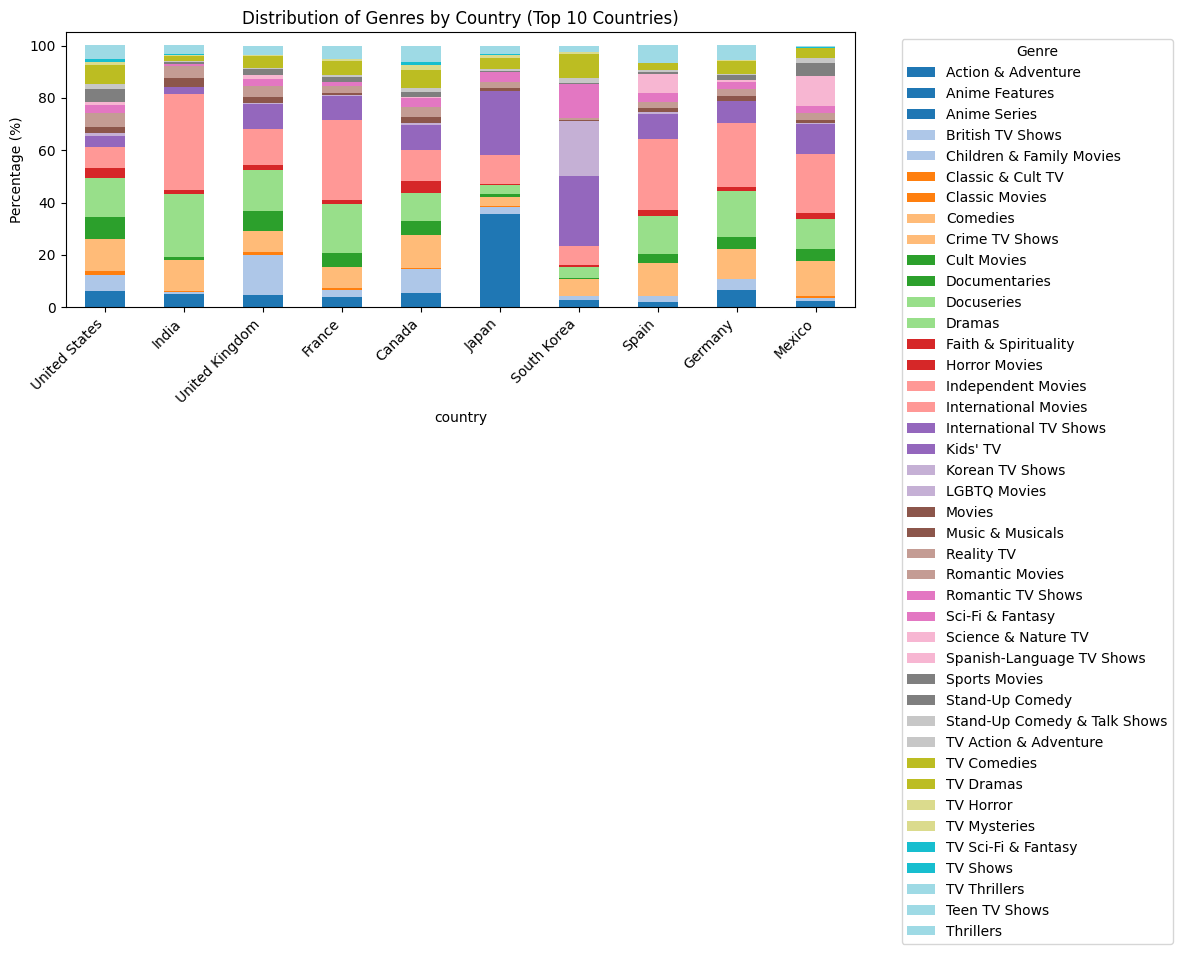

In [254]:
tbl_top_countries.plot(kind="bar", stacked=True, figsize=(12,7), colormap="tab20")
plt.ylabel("Percentage (%)")
plt.title("Distribution of Genres by Country (Top 10 Countries)")
plt.xticks(rotation=45, ha="right")
plt.legend(title="Genre", bbox_to_anchor=(1.05, 1))
plt.tight_layout()
plt.show()

In [255]:
df_movies = df[df["duration"].str.contains("min", na=False)].copy()
df_movies["duration"] = df_movies["duration"].str.extract("(\\d+)").astype(int)

In [256]:
df_tv = df[df["duration"].str.contains("Season", na=False)].copy()
df_tv["seasons"] = df_tv["duration"].str.extract("(\\d+)").astype(int)

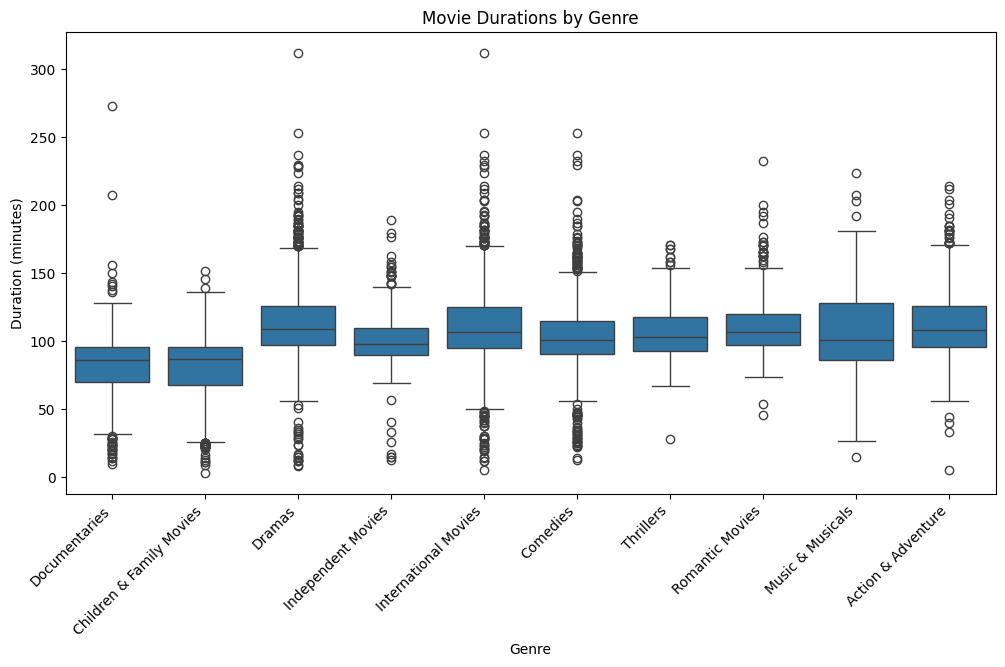

In [257]:
df_movies_exp = df_movies.dropna(subset=["listed_in"]).copy()
df_movies_exp["listed_in"] = df_movies_exp["listed_in"].str.split(", ")
df_movies_exp = df_movies_exp.explode("listed_in")

top_genres = df_movies_exp["listed_in"].value_counts().head(10).index
df_movies_exp = df_movies_exp[df_movies_exp["listed_in"].isin(top_genres)]

plt.figure(figsize=(12,6))
sns.boxplot(x="listed_in", y="duration", data=df_movies_exp)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Duration (minutes)")
plt.xlabel("Genre")
plt.title("Movie Durations by Genre")
plt.show()

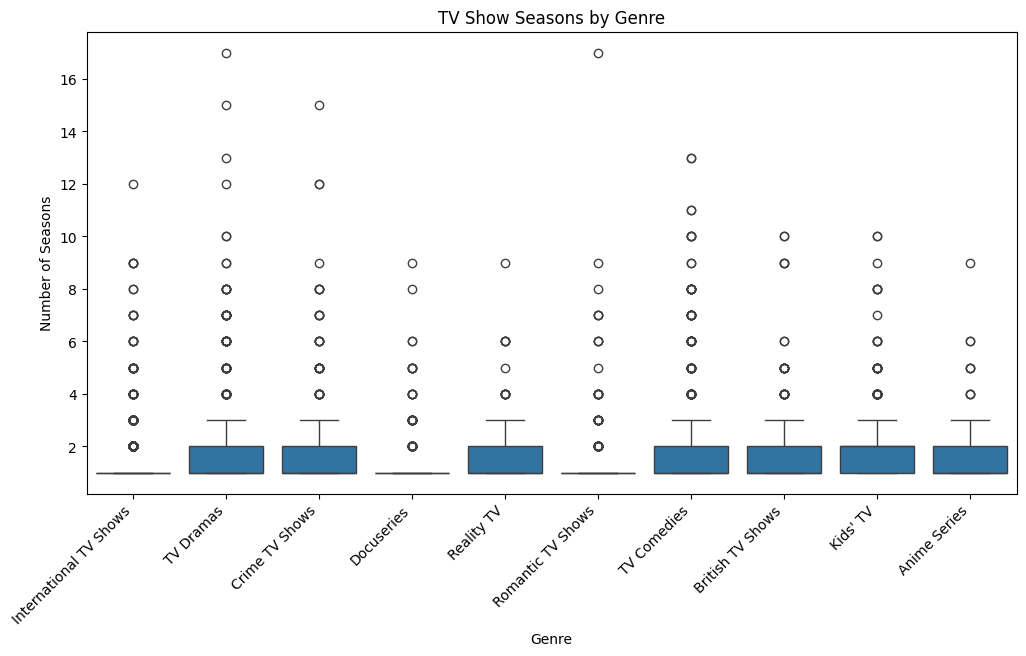

In [258]:
df_tv_exp = df_tv.dropna(subset=["listed_in"]).copy()
df_tv_exp["listed_in"] = df_tv_exp["listed_in"].str.split(", ")
df_tv_exp = df_tv_exp.explode("listed_in")
top_genres_tv = df_tv_exp["listed_in"].value_counts().head(10).index
df_tv_exp = df_tv_exp[df_tv_exp["listed_in"].isin(top_genres_tv)]

plt.figure(figsize=(12,6))
sns.boxplot(x="listed_in", y="seasons", data=df_tv_exp)
plt.xticks(rotation=45, ha="right")
plt.ylabel("Number of Seasons")
plt.xlabel("Genre")
plt.title("TV Show Seasons by Genre")
plt.show()